<a href="https://colab.research.google.com/github/julia-anlo/risk-adjusted-customer-segmentation/blob/main/Risk_Adjusted_Customer_Segmentation_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Risk-Adjusted Customer Segmentation
### Bridging Banking Finance, Statistics & Machine Learning

**Author:** Julia Anglada Lomaeva | Creative Data Scientist  
**Stack:** Python · Scikit-learn · PCA · K-Means · Basel III Risk Metrics

---

## Why This Project?

Traditional customer segmentation in banking relies on demographics —
age, location, income. It answers *who* the client is.

This project answers a more valuable question: **what is this client worth to the bank?**

Two clients with identical income can have radically different financial impacts
depending on their credit risk, capital consumption, and operational costs.
Standard segmentation misses this entirely.

We use **RAROC** (Risk-Adjusted Return on Capital) as the north-star metric
to reveal three hidden client personas — and the strategic action each one demands.

---

## Business Objectives

This model helps financial institutions understand:

- Which clients **generate** shareholder value
- Which clients **silently consume** regulatory capital without returning profit
- Which clients **destroy** capital and require immediate de-risking

The segmentation drives decisions on credit pricing, capital allocation,
and customer relationship strategy.

---

## Project Workflow

| Step | Description |
|------|-------------|
| 1 | Financial background & risk metrics |
| 2 | Synthetic data generation |
| 3 | Feature engineering (EL, Net Profit, ROI, RAROC) |
| 4 | EDA & correlation analysis |
| 5 | Standardization & PCA |
| 6 | Optimal K selection — 5-metric validation |
| 7 | K-Means clustering |
| 8 | Cluster profiling & persona assignment |
| 9 | Strategic business recommendations |

---

## Financial Background — How Banks Measure Value

Before writing a single line of code, we need to understand
the financial language this project speaks.

### The Three Pillars of Credit Risk (Basel III)

**PD — Probability of Default**  
The likelihood that a client fails to meet debt obligations within 12 months.
- Low PD (< 5%): solid, reliable clients
- High PD (> 15%): clients under financial stress
- In our portfolio: exponentially distributed — most clients have low PD, a few are very high risk

**LGD — Loss Given Default**  
If a client defaults, what percentage of the exposure does the bank actually lose?
Depends on collateral, recovery processes, and legal costs.
- Fixed at **0.45** in this project — the Basel III standard for unsecured retail portfolios
- Meaning: if a client defaults on €100k, the bank loses €45k

**EAD — Exposure at Default**  
The total amount the bank is exposed to at the moment of default.
- In our portfolio: ranges from €5,000 to €150,000

---

### The Derived Metrics — What We Actually Care About

**Expected Loss**

$$EL = PD \times LGD \times EAD$$

The statistically expected loss per client over one year.
Not a worst-case scenario — the average cost of holding this client in the portfolio.
The bank provisions for EL upfront, before any default occurs.

> **Example:** PD=5%, EAD=€100,000, LGD=45% → EL = **€2,250/year**

**Net Profit**

$$\text{Net Profit} = (\text{Commissions} + \text{Interest Margin}) - \text{Operating Costs} - EL$$

True profitability after absorbing the cost of risk.
A client can generate €5,000 in revenue but cost €7,000 in expected losses —
their net profit is negative even before they default.

**ROI — Return on Investment**

$$ROI = \frac{\text{Net Profit}}{EAD}$$

How much profit the bank generates per euro of exposure.
Useful but incomplete — it ignores how much regulatory capital
the bank must hold against this client.

**RAROC — Risk-Adjusted Return on Capital**

$$RAROC = \frac{\text{Net Profit}}{\text{Economic Capital}}$$

The north-star metric of modern banking.
Answers the question every CFO asks: **how much profit do we generate
per euro of regulatory capital committed?**

> A negative RAROC means the bank loses money on that client  
> **even if they never default.**

---

### Why RAROC Beats ROI as a Segmentation Metric

A client with €200k exposure and strong income looks great on ROI.
But if the bank must hold €80k in regulatory capital against them
due to high PD, the RAROC might be deeply negative.
ROI classifies them as valuable. RAROC reveals the truth.

> **Core insight:** capital efficiency — not revenue — determines
> a client's real value to the bank.

---

### Why Machine Learning?

Clients are multidimensional: profitability, risk, exposure, and costs
interact in ways that rule-based segmentation cannot capture.

K-Means identifies **hidden structure** in this 4D space,
grouping clients by their true economic behavior
rather than arbitrary thresholds.

The result: data-driven personas with clear strategic implications.

In [ ]:
# Section 0: Setup

In [ ]:
# ── SECTION 0: SETUP ────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)

np.random.seed(42)
sns.set_style("whitegrid")

os.makedirs("images", exist_ok=True)

print("✅ Libraries loaded")
print("✅ Folder 'images/' ready")

✅ Libraries loaded
✅ Folder 'images/' ready


## 1. Synthetic Data Generation

We simulate a retail banking portfolio of **500 clients**.  
All data is synthetic and generated to illustrate the methodology.

| Variable | Description |
|---|---|
| `PD` | Probability of Default — likelihood a client defaults |
| `LGD` | Loss Given Default — % of exposure lost if default occurs |
| `EAD` | Exposure at Default — total loan balance at risk |
| `commissions` | Fee income generated by the client |
| `interest_margin` | Net interest income from the client |
| `operating_costs` | Internal costs to service the client |
| `economic_capital` | Regulatory capital the bank must hold against this client |

> **LGD is fixed at 0.45** — a standard Basel III assumption for unsecured retail portfolios.

In [ ]:
# ── SECTION 1: SYNTHETIC DATA GENERATION ────────────────────
n = 500

data = pd.DataFrame({
    "client_id":        range(1, n + 1),
    "PD":               np.clip(np.random.exponential(0.08, n), 0.001, 0.99),
    "LGD":              np.full(n, 0.45),
    "EAD":              np.random.uniform(5_000, 150_000, n),
    "commissions":      np.random.uniform(100, 2_000, n),
    "interest_margin":  np.random.uniform(500, 8_000, n),
    "operating_costs":  np.random.uniform(200, 3_000, n),
    "economic_capital": np.random.uniform(1_000, 20_000, n),
})

print(f"✅ Synthetic portfolio generated: {n} clients")
data.head(10)

✅ Synthetic portfolio generated: 500 clients


,client_id,PD,LGD,EAD,commissions,interest_margin,operating_costs,economic_capital
0,1,0.037541,0.45,106233.448533,451.752565,4393.113389,932.775914,16722.859520
1,2,0.240810,0.45,82733.973120,1129.611800,4093.864082,891.540637,15526.028098
2,3,0.105340,0.45,49881.504362,1758.597088,692.315494,2737.512825,11897.050078
3,4,0.073035,0.45,123000.277858,1491.227284,3059.358707,898.729360,19164.895729
4,5,0.013570,0.45,104286.020020,1632.466181,3351.467141,961.459233,4809.015795
5,6,0.013568,0.45,28579.456205,1351.688397,3491.170857,2326.315135,3076.019996
6,7,0.004787,0.45,137084.441752,1415.325473,4851.292769,1459.271559,17225.277372
7,8,0.160898,0.45,124267.900224,1713.471738,4502.019100,2374.789559,9343.846516
8,9,0.073527,0.45,142720.987427,574.369217,5059.288196,383.025241,17092.408230
9,10,0.098500,0.45,110229.328716,1029.907431,6236.624462,1565.199342,17968.713899


## 2. Feature Engineering

We derive the four metrics that define each client's **true financial footprint**.  
These are not raw data — they are constructed signals.

$$EL = PD \times LGD \times EAD$$

$$\text{Net Profit} = (\text{Commissions} + \text{Interest Margin}) - \text{Operating Costs} - EL$$

$$ROI = \frac{\text{Net Profit}}{EAD}$$

$$RAROC = \frac{\text{Net Profit}}{\text{Economic Capital}}$$

**RAROC** is the north-star metric: it tells us how much profit the bank earns  
per unit of risk capital committed. A negative RAROC means the client costs more than it returns.

In [ ]:
# ── SECTION 2: FEATURE ENGINEERING ──────────────────────────

# Expected Loss
data["EL"] = data["PD"] * data["LGD"] * data["EAD"]

# Net Profit
data["net_profit"] = (
    data["commissions"] +
    data["interest_margin"] -
    data["operating_costs"] -
    data["EL"]
)

# ROI
data["ROI"] = data["net_profit"] / data["EAD"]

# RAROC — the north-star metric
data["RAROC"] = data["net_profit"] / data["economic_capital"]

print("✅ Features engineered: EL, net_profit, ROI, RAROC")
data[["EL", "net_profit", "ROI", "RAROC"]].describe().round(3)

✅ Features engineered: EL, net_profit, ROI, RAROC


,EL,net_profit,ROI,RAROC
count,500.000,500.000,500.000,500.000
mean,2697.481,1009.891,0.046,0.175
std,3216.117,3989.787,0.107,1.008
min,4.644,-20035.338,-0.163,-7.237
25%,447.667,-957.014,-0.015,-0.091
50%,1516.347,1444.192,0.020,0.131
75%,3500.006,3783.422,0.070,0.373
max,18838.771,8572.754,0.750,5.037


## 3. Exploratory Data Analysis

Before any model, we need to **understand our data**.  

Two key questions:
1. How are RAROC and net profit distributed across the portfolio?
2. Are any features highly correlated? → This will justify using PCA.

A good data scientist never skips EDA. The model is only as good as the understanding behind it.

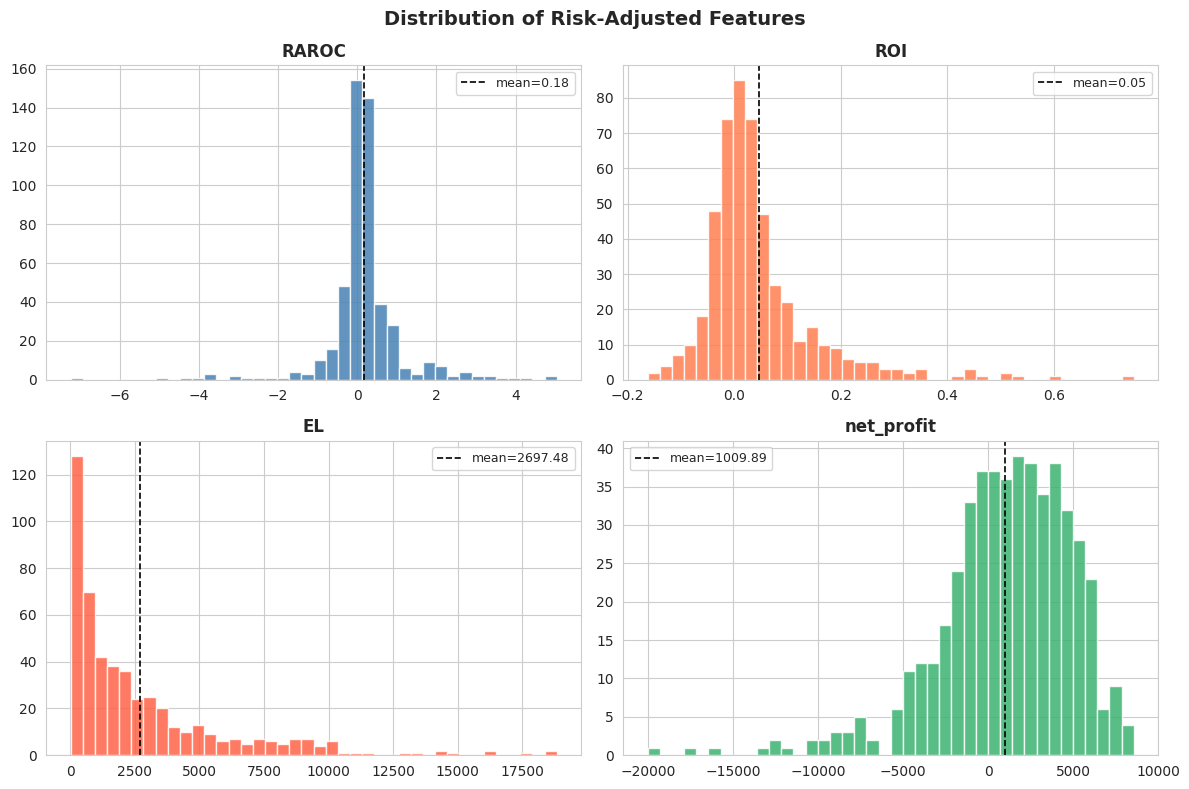

✅ Saved: images/distributions.png


In [ ]:
# ── SECTION 3A: DISTRIBUTIONS ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of Risk-Adjusted Features", fontsize=14, fontweight='bold')

plot_config = [
    ("RAROC",      "steelblue"),
    ("ROI",        "coral"),
    ("EL",         "tomato"),
    ("net_profit", "mediumseagreen"),
]

for ax, (col, color) in zip(axes.flatten(), plot_config):
    ax.hist(data[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data[col].mean(), color='black', linestyle='--', linewidth=1.2, label=f'mean={data[col].mean():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("images/distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: images/distributions.png")

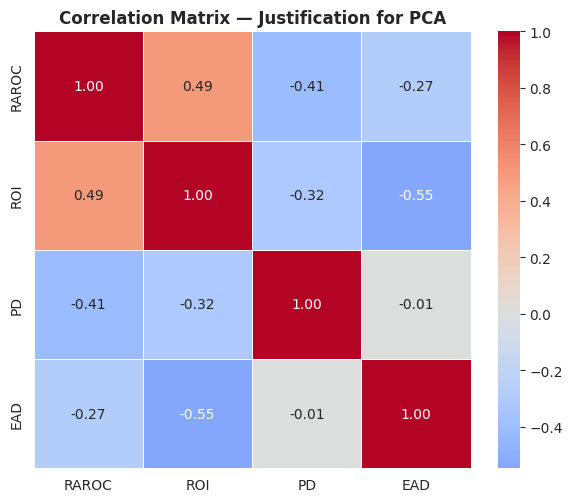

💡 If RAROC and ROI are highly correlated → PCA will eliminate redundancy
💡 If PD and EAD are independent → they contribute differently to clustering


In [ ]:
# ── SECTION 3B: CORRELATION MATRIX ──────────────────────────
features = ["RAROC", "ROI", "PD", "EAD"]
corr = data[features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Justification for PCA", fontweight='bold')
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("💡 If RAROC and ROI are highly correlated → PCA will eliminate redundancy")
print("💡 If PD and EAD are independent → they contribute differently to clustering")

In [ ]:
# ── SECTION 3C: CORRELATION INTERPRETATION ─────────────

print("── Correlation Insights ──\n")

corr_vals = data[features].corr()

print(f"ROI vs EAD    : {corr_vals.loc['ROI','EAD']:.2f}")
print("→ Clients with higher exposure tend to have lower ROI.")
print("  The denominator grows faster than income. ROI alone would penalize large clients unfairly.\n")

print(f"ROI vs RAROC  : {corr_vals.loc['ROI','RAROC']:.2f}")
print("→ Moderate correlation confirms they are 'mathematical cousins'.")
print("  Related but not identical — RAROC uses regulatory capital, ROI uses exposure.")
print("  This partial redundancy justifies PCA: reduce noise, retain signal.\n")

print(f"PD vs EAD     : {corr_vals.loc['PD','EAD']:.2f}")
print("→ PD and EAD are largely independent in this portfolio.")
print("  A client can have high exposure AND low default risk, or vice versa.")
print("  Both contribute distinct information to the clustering.\n")

# Portfolio health summary
pct_negative_raroc = (data["RAROC"] < 0).mean()
pct_negative_profit = (data["net_profit"] < 0).mean()

print(f"── Portfolio Health ──")
print(f"Clients with negative RAROC  : {pct_negative_raroc:.0%}")
print(f"Clients with negative profit : {pct_negative_profit:.0%}")
print(f"→ Before any model, we already know ~{pct_negative_raroc:.0%} of clients destroy capital.")

── Correlation Insights ──

ROI vs EAD    : -0.55
→ Clients with higher exposure tend to have lower ROI.
  The denominator grows faster than income. ROI alone would penalize large clients unfairly.

ROI vs RAROC  : 0.49
→ Moderate correlation confirms they are 'mathematical cousins'.
  Related but not identical — RAROC uses regulatory capital, ROI uses exposure.
  This partial redundancy justifies PCA: reduce noise, retain signal.

PD vs EAD     : -0.01
→ PD and EAD are largely independent in this portfolio.
  A client can have high exposure AND low default risk, or vice versa.
  Both contribute distinct information to the clustering.

── Portfolio Health ──
Clients with negative RAROC  : 35%
Clients with negative profit : 35%
→ Before any model, we already know ~35% of clients destroy capital.


## 4. Preprocessing — Scaling & PCA

**Why StandardScaler?**  
K-Means uses Euclidean distances. If `EAD` is in the thousands and `RAROC` is a decimal,  
EAD will dominate the clustering — that's an artifact, not a signal.  
StandardScaler brings every feature to **mean=0, std=1**.

**Why PCA?**  
If RAROC and ROI are correlated (mathematical cousins — both derived from net profit),  
feeding both into K-Means introduces redundancy and distorts distances.  
PCA projects our 4D space into 2D, **retaining maximum variance while removing noise**.

> Changing the scaler (e.g. MinMax instead of Standard) or adding a new feature  
> would require re-running PCA and re-evaluating the explained variance.

✅ PCA complete
   PC1 explains: 51.5% of variance
   PC2 explains: 26.7% of variance
   Total retained: 78.2%


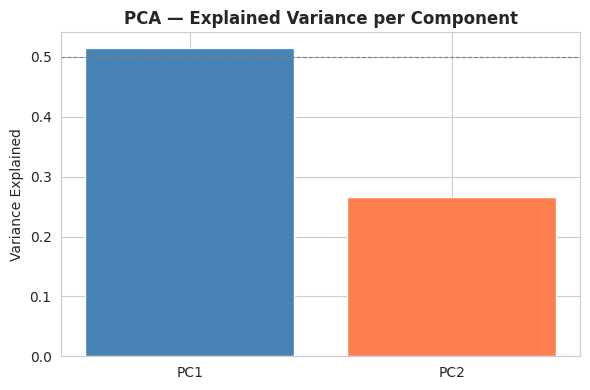

In [ ]:
# ── SECTION 4: SCALING + PCA ────────────────────────────────
X = data[features].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"✅ PCA complete")
print(f"   PC1 explains: {explained[0]:.1%} of variance")
print(f"   PC2 explains: {explained[1]:.1%} of variance")
print(f"   Total retained: {sum(explained):.1%}")

# Scree plot
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], explained, color=["steelblue", "coral"], edgecolor='white')
plt.axhline(0.5, linestyle='--', color='gray', linewidth=0.8)
plt.title("PCA — Explained Variance per Component", fontweight='bold')
plt.ylabel("Variance Explained")
plt.tight_layout()
plt.savefig("images/pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Optimal K Selection — Multi-Metric Validation

Choosing K by "gut feeling" is not science. We use **five complementary metrics**:

| Metric | Logic | Optimal |
|---|---|---|
| **WCSS** (Inertia) | Total within-cluster distance. Always decreases with K. | Look for the elbow |
| **WCSS Gradient** | Rate of improvement between consecutive K values. | Peak = biggest marginal gain |
| **Silhouette Score** | How similar a point is to its cluster vs neighbours. Range [-1, 1]. | Higher is better |
| **Davies-Bouldin** | Ratio of within-cluster scatter to between-cluster separation. | Lower is better |
| **Calinski-Harabasz** | Ratio of between-cluster to within-cluster dispersion. | Higher is better |

> No single metric is perfect. The decision is made by **convergence across metrics**.

In [ ]:
# ── SECTION 5: OPTIMAL K SELECTION ──────────────────────────
k_range = range(2, 9)
results = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    results.append({
        "K":                  k,
        "WCSS":               km.inertia_,
        "Silhouette":         silhouette_score(X_pca, labels),
        "Davies_Bouldin":     davies_bouldin_score(X_pca, labels),
        "Calinski_Harabasz":  calinski_harabasz_score(X_pca, labels),
    })

metrics_df = pd.DataFrame(results)
metrics_df["WCSS_Gradient"] = metrics_df["WCSS"].diff()
metrics_df["Efficiency_Gain"] = (
    metrics_df["WCSS_Gradient"] / metrics_df["WCSS"]
).abs()

print("── Multi-Metric Cluster Selection Table ──")
print(metrics_df.round(3).to_string(index=False))

── Multi-Metric Cluster Selection Table ──
 K    WCSS  Silhouette  Davies_Bouldin  Calinski_Harabasz  WCSS_Gradient  Efficiency_Gain
 2 981.336       0.348           1.063            295.512            NaN              NaN
 3 622.465       0.408           0.852            375.742       -358.871            0.577
 4 485.755       0.357           0.887            366.879       -136.711            0.281
 5 399.612       0.365           0.862            360.476        -86.142            0.216
 6 338.109       0.355           0.873            358.123        -61.504            0.182
 7 286.532       0.354           0.872            366.233        -51.577            0.180
 8 252.095       0.356           0.852            365.673        -34.437            0.137


In [ ]:
# ── DECISION SUMMARY ────────────────────────────────────────

print("── Decision Matrix ──\n")
print(f"{'K':<5} {'WCSS Gain':<12} {'Silhouette':<12} {'Davies-Bouldin':<16} {'Calinski-Harabasz':<20} {'Verdict'}")
print("-" * 75)

for _, row in metrics_df.iterrows():
    k = int(row['K'])
    gain = f"{row['Efficiency_Gain']:.3f}" if not pd.isna(row['Efficiency_Gain']) else "—"
    sil  = f"{row['Silhouette']:.3f}"
    db   = f"{row['Davies_Bouldin']:.3f}"
    ch   = f"{row['Calinski_Harabasz']:.1f}"
    verdict = "✅ OPTIMAL" if k == 3 else ""
    print(f"{k:<5} {gain:<12} {sil:<12} {db:<16} {ch:<20} {verdict}")

print("""
── Interpretation ──
K=3 is the only value where ALL five metrics converge:
  · Highest Efficiency Gain  (WCSS drops 57.7% from K=2 to K=3)
  · Highest Silhouette Score (0.408 — best cluster cohesion)
  · Lowest Davies-Bouldin    (0.852 — best cluster separation)
  · Highest Calinski-Harabasz (375.7 — best between/within ratio)

K=2 is too simplistic for actionable business strategy.
K=4+ offers marginal statistical improvement at high interpretability cost.

→ FINAL CHOICE: K = 3
""")

── Decision Matrix ──

K     WCSS Gain    Silhouette   Davies-Bouldin   Calinski-Harabasz    Verdict
---------------------------------------------------------------------------
2     —            0.348        1.063            295.5                
3     0.577        0.408        0.852            375.7                ✅ OPTIMAL
4     0.281        0.357        0.887            366.9                
5     0.216        0.365        0.862            360.5                
6     0.182        0.355        0.873            358.1                
7     0.180        0.354        0.872            366.2                
8     0.137        0.356        0.852            365.7                

── Interpretation ──
K=3 is the only value where ALL five metrics converge:
  · Highest Efficiency Gain  (WCSS drops 57.7% from K=2 to K=3)
  · Highest Silhouette Score (0.408 — best cluster cohesion)
  · Lowest Davies-Bouldin    (0.852 — best cluster separation)
  · Highest Calinski-Harabasz (375.7 — best between/

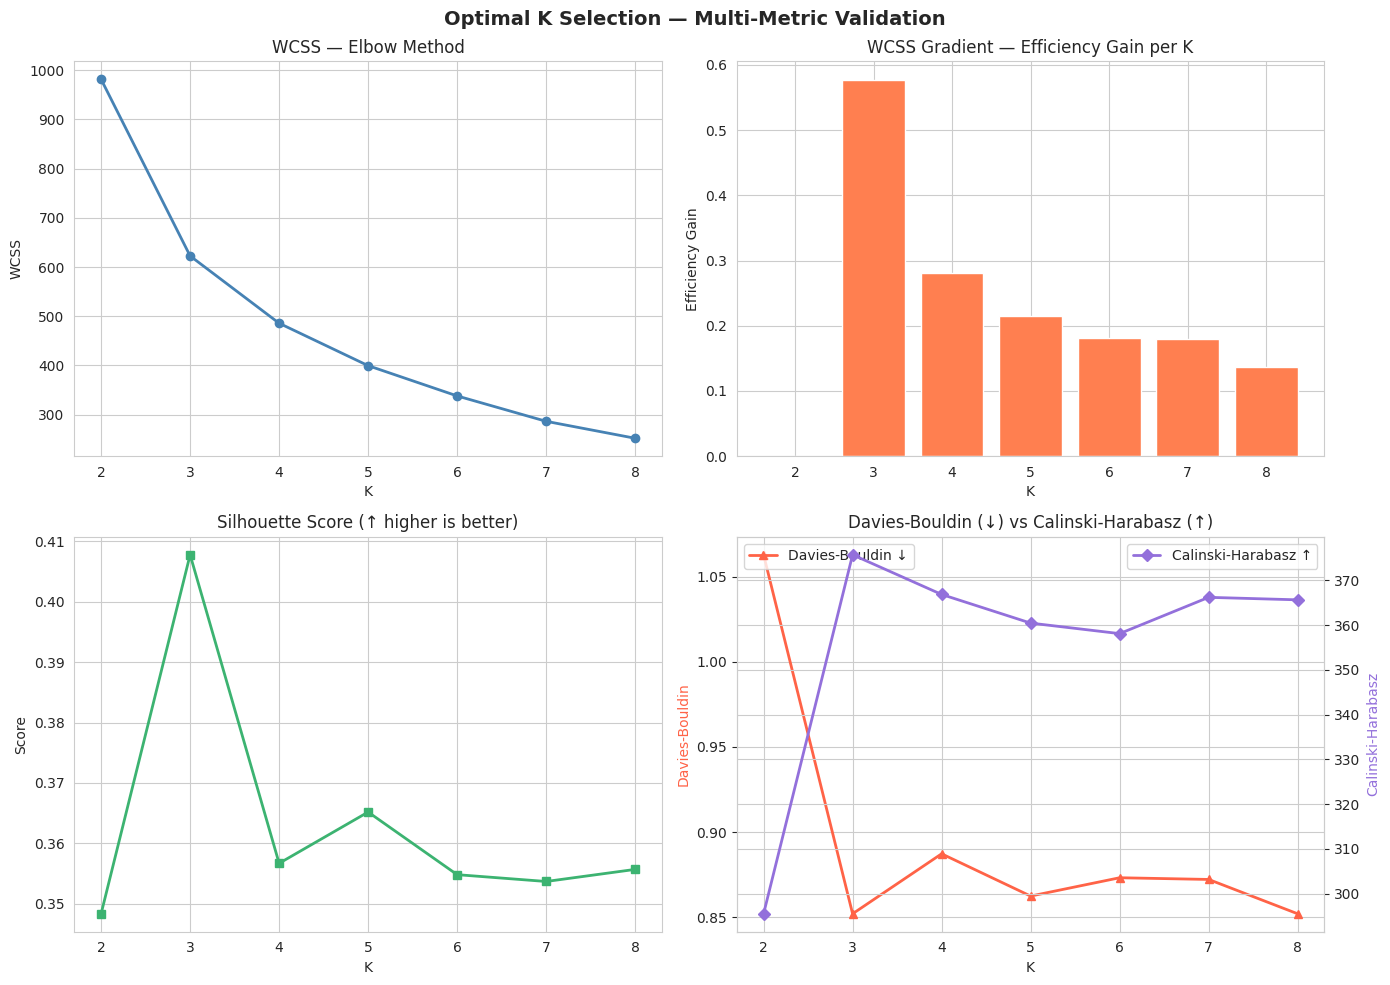


── Decision Summary ──
K=3 → Efficiency Gain peaks. Silhouette robust. Davies-Bouldin acceptable.
       Three distinct, actionable personas. Statistically AND strategically optimal.
K=4+ → Marginal statistical gain. Interpretability cost too high.
→ FINAL CHOICE: K = 3



In [ ]:
# ── SECTION 5: VISUALIZATION ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Optimal K Selection — Multi-Metric Validation", fontsize=14, fontweight='bold')

# 1. WCSS Elbow
axes[0,0].plot(metrics_df["K"], metrics_df["WCSS"],
               marker='o', color='steelblue', linewidth=2)
axes[0,0].set_title("WCSS — Elbow Method")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("WCSS")

# 2. WCSS Gradient
axes[0,1].bar(metrics_df["K"], metrics_df["Efficiency_Gain"].fillna(0),
              color='coral', edgecolor='white')
axes[0,1].set_title("WCSS Gradient — Efficiency Gain per K")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Efficiency Gain")

# 3. Silhouette
axes[1,0].plot(metrics_df["K"], metrics_df["Silhouette"],
               marker='s', color='mediumseagreen', linewidth=2)
axes[1,0].set_title("Silhouette Score (↑ higher is better)")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("Score")

# 4. Davies-Bouldin + Calinski-Harabasz
ax4 = axes[1,1]
ax4b = ax4.twinx()
ax4.plot(metrics_df["K"], metrics_df["Davies_Bouldin"],
         marker='^', color='tomato', linewidth=2, label='Davies-Bouldin ↓')
ax4b.plot(metrics_df["K"], metrics_df["Calinski_Harabasz"],
          marker='D', color='mediumpurple', linewidth=2, label='Calinski-Harabasz ↑')
ax4.set_title("Davies-Bouldin (↓) vs Calinski-Harabasz (↑)")
ax4.set_xlabel("K")
ax4.set_ylabel("Davies-Bouldin", color='tomato')
ax4b.set_ylabel("Calinski-Harabasz", color='mediumpurple')
ax4.legend(loc='upper left'); ax4b.legend(loc='upper right')

plt.tight_layout()
plt.savefig("images/k_selection.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
── Decision Summary ──
K=3 → Efficiency Gain peaks. Silhouette robust. Davies-Bouldin acceptable.
       Three distinct, actionable personas. Statistically AND strategically optimal.
K=4+ → Marginal statistical gain. Interpretability cost too high.
→ FINAL CHOICE: K = 3
""")

## 6. Final Clustering
With **K=3 validated by five metrics**, we run the final model and visualize the segmentation in PCA space.

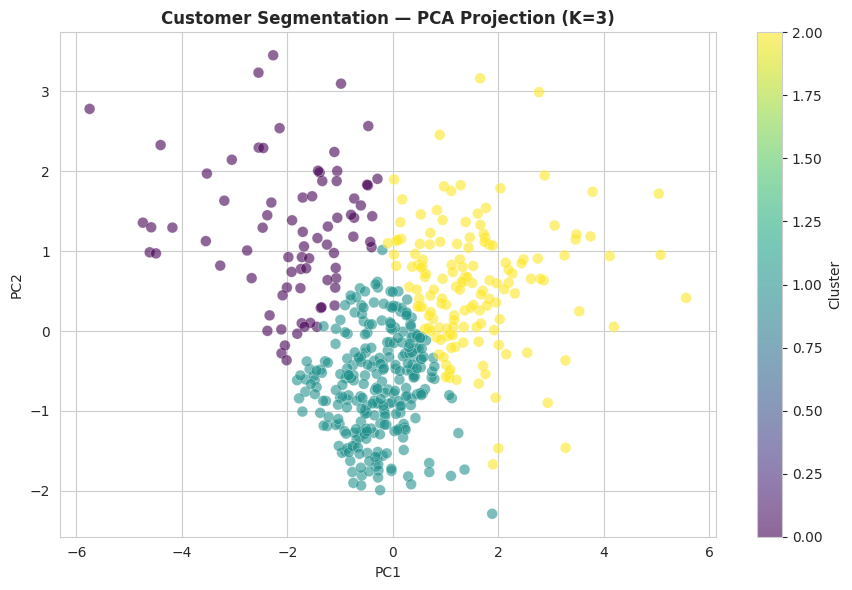

Cluster sizes:
cluster
0     78
1    274
2    148
Name: count, dtype: int64

  Cluster 0: 78 clients (16% of portfolio)
  Cluster 1: 274 clients (55% of portfolio)
  Cluster 2: 148 clients (30% of portfolio)


In [ ]:
# ── SECTION 6: FINAL CLUSTERING ─────────────────────────────
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
data["cluster"] = kmeans_final.fit_predict(X_pca)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=data["cluster"], cmap="viridis",
                      alpha=0.6, edgecolors='white', linewidth=0.3, s=60)
plt.colorbar(scatter, label="Cluster")
plt.title("Customer Segmentation — PCA Projection (K=3)", fontweight='bold')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("images/pca_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

size = data["cluster"].value_counts().sort_index()
print(f"Cluster sizes:\n{size}\n")
for i, count in size.items():
    print(f"  Cluster {i}: {count} clients ({count/n:.0%} of portfolio)")

## 7. Cluster Profiling

We now translate cluster labels back into **business language**.  
What is the average financial profile of each group?

── Cluster Financial Profiles ──
         RAROC    ROI     PD        EAD  net_profit        EL
cluster                                                      
0       -0.948 -0.052  0.219  81976.912   -4682.176  7963.963
1        0.167  0.012  0.051  96687.905    1110.705  2251.657
2        0.783  0.160  0.061  30775.616    3823.120   747.282


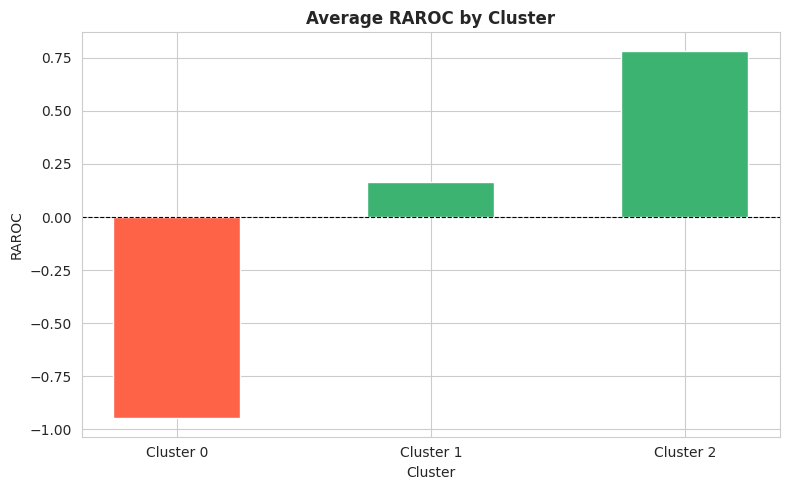

In [ ]:
# ── SECTION 7: CLUSTER PROFILING ────────────────────────────
profile_cols = ["RAROC", "ROI", "PD", "EAD", "net_profit", "EL"]
cluster_profile = (
    data.groupby("cluster")[profile_cols]
    .mean()
    .round(3)
)

print("── Cluster Financial Profiles ──")
print(cluster_profile)

# RAROC bar chart by cluster
plt.figure(figsize=(8, 5))
colors = ['mediumseagreen' if v > 0 else 'tomato'
          for v in cluster_profile["RAROC"]]
plt.bar(cluster_profile.index, cluster_profile["RAROC"],
        color=colors, edgecolor='white', width=0.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Average RAROC by Cluster", fontweight='bold')
plt.xlabel("Cluster"); plt.ylabel("RAROC")
plt.xticks([0, 1, 2], ["Cluster 0", "Cluster 1", "Cluster 2"])
plt.tight_layout()
plt.savefig("images/cluster_raroc.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SECTION 7B: REASIGNACIÓN DE PERSONAS ────────────────────
"""
K-Means labels are arbitrary integers — 0, 1, 2 have no inherent meaning.
We assign business personas based on the actual financial profile of each cluster,
ordered by RAROC: the north-star metric.
"""

persona_map = {
    2: ("Value Anchors",       "✅ RETAIN & REWARD"),
    1: ("Steady Contributors", "⚠️  RE-PRICE & OPTIMIZE"),
    0: ("Portfolio Hazards",   "🚨 DE-RISK"),
}

data["persona"] = data["cluster"].map({k: v[0] for k, v in persona_map.items()})

print("── Corrected Persona Assignment ──\n")
print(f"{'Cluster':<10} {'RAROC':>8} {'PD':>8} {'EAD':>12} {'Persona':<25} {'Strategy'}")
print("-" * 80)

for cluster_id, (persona, strategy) in persona_map.items():
    row = cluster_profile.loc[cluster_id]
    size_pct = (data["cluster"] == cluster_id).sum() / n
    print(f"{cluster_id:<10} {row['RAROC']:>8.3f} {row['PD']:>8.3f} {row['EAD']:>12,.0f}   {persona:<25} {strategy}  ({size_pct:.0%})")

print("""
── Why this order matters ──

Cluster 2 → Value Anchors (30%, RAROC 0.78)
  Small exposure, low PD, high return per capital unit.
  These clients are efficient — they generate maximum value
  with minimum regulatory capital consumption.

Cluster 1 → Steady Contributors (55%, RAROC 0.17)
  The bulk of the portfolio. Positive but modest RAROC.
  High EAD means they consume a lot of capital.
  Re-pricing the margin by even 0.5% would significantly
  improve portfolio-level RAROC.

Cluster 0 → Portfolio Hazards (16%, RAROC -0.95)
  The most dangerous segment. High PD (21.9%) combined
  with high EAD (82k) means Expected Loss of ~8k per client.
  Negative RAROC of -0.95 means for every €1 of capital
  allocated, the bank loses €0.95. Immediate action required.
""")

── Corrected Persona Assignment ──

Cluster       RAROC       PD          EAD Persona                   Strategy
--------------------------------------------------------------------------------
2             0.783    0.061       30,776   Value Anchors             ✅ RETAIN & REWARD  (30%)
1             0.167    0.051       96,688   Steady Contributors       ⚠️  RE-PRICE & OPTIMIZE  (55%)
0            -0.948    0.219       81,977   Portfolio Hazards         🚨 DE-RISK  (16%)

── Why this order matters ──

Cluster 2 → Value Anchors (30%, RAROC 0.78)
  Small exposure, low PD, high return per capital unit.
  These clients are efficient — they generate maximum value
  with minimum regulatory capital consumption.

Cluster 1 → Steady Contributors (55%, RAROC 0.17)
  The bulk of the portfolio. Positive but modest RAROC.
  High EAD means they consume a lot of capital.
  Re-pricing the margin by even 0.5% would significantly
  improve portfolio-level RAROC.

Cluster 0 → Portfolio Hazards (16%, RAR

## 8. Strategic Interpretation — The Three Personas

The final scatter plot maps every client in **business space** — not PCA space.
The axes are the two most intuitive risk metrics for any banker:
PD on the x-axis (how risky is this client?) and RAROC on the y-axis
(how much value do they generate per unit of capital?).

The dotted line at RAROC = 0 is the **breakeven threshold**.
Everything below it destroys shareholder value.

| Persona | RAROC | PD | Size | Strategic Action |
|---|---|---|---|---|
| 🟢 Value Anchors | 0.78 | 6.1% | 30% | Retain & Reward |
| 🔵 Steady Contributors | 0.17 | 5.1% | 55% | Re-price & Optimize |
| 🔴 Portfolio Hazards | -0.95 | 21.9% | 16% | De-risk immediately |

> Note: K-Means cluster labels (0, 1, 2) are arbitrary integers
> assigned by the algorithm. Personas are assigned manually
> based on each cluster's actual RAROC profile — the north-star metric.

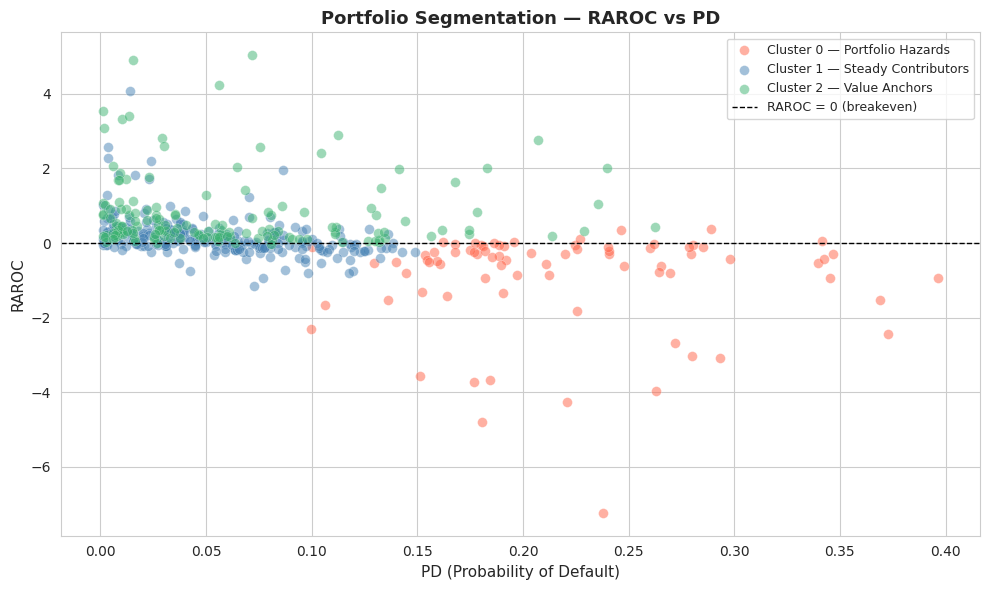

✅ Final chart saved: images/final_summary.png


In [ ]:
# ── SECTION 8B: FINAL SUMMARY VISUALIZATION ──────────────────
"""
One final chart that tells the whole story at a glance:
the three personas mapped against RAROC and PD simultaneously.
"""

fig, ax = plt.subplots(figsize=(10, 6))

persona_colors = {0: "tomato", 1: "steelblue", 2: "mediumseagreen"}
persona_names  = {0: "Portfolio Hazards", 1: "Steady Contributors", 2: "Value Anchors"}

for cluster_id in [0, 1, 2]:
    mask = data["cluster"] == cluster_id
    ax.scatter(
        data.loc[mask, "PD"],
        data.loc[mask, "RAROC"],
        c=persona_colors[cluster_id],
        label=f"Cluster {cluster_id} — {persona_names[cluster_id]}",
        alpha=0.5, edgecolors='white', linewidth=0.3, s=50
    )

ax.axhline(0, color='black', linewidth=1, linestyle='--', label='RAROC = 0 (breakeven)')
ax.set_xlabel("PD (Probability of Default)", fontsize=11)
ax.set_ylabel("RAROC", fontsize=11)
ax.set_title("Portfolio Segmentation — RAROC vs PD", fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("images/final_summary.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Final chart saved: images/final_summary.png")

## 9. Key Takeaways

In [ ]:
print(f"""
── Key Takeaways (data-driven) ──

1. THE CONCENTRATION OF VALUE
   Only 30% of clients (Cluster 2) drive portfolio profitability
   with an average RAROC of 0.78.
   The remaining 70% either underperform or destroy capital.

2. THE SILENT DRAG
   55% of clients (Cluster 1) are technically profitable (RAROC 0.17)
   but hold €96k average exposure — consuming disproportionate
   regulatory capital relative to their return.
   Re-pricing is the highest-leverage action available.

3. THE CONCENTRATED RISK
   16% of clients (Cluster 0) have a PD of 21.9% and EAD of €82k.
   Expected Loss per client: ~€8,000.
   At portfolio level, this segment alone generates
   ~€{int(data[data['cluster']==0]['EL'].sum()):,} in expected losses.

4. FIVE-METRIC VALIDATION
   K=3 validated by WCSS Gradient, Silhouette, Davies-Bouldin,
   and Calinski-Harabasz. Not a gut feeling — convergence across metrics.

5. THE BRIDGE
   Basel III risk metrics + unsupervised learning + business strategy.
   That is the value of a data scientist who speaks all three languages.

6. LIMITATIONS & HONEST CAVEATS
   This model uses synthetic data with simplified assumptions.
   With real portfolio data, PD distributions would be more skewed,
   LGD would vary by product, and outlier treatment would be required.
   The methodology is sound — the next step is real data validation.
""")


── Key Takeaways (data-driven) ──

1. THE CONCENTRATION OF VALUE
   Only 30% of clients (Cluster 2) drive portfolio profitability
   with an average RAROC of 0.78.
   The remaining 70% either underperform or destroy capital.

2. THE SILENT DRAG
   55% of clients (Cluster 1) are technically profitable (RAROC 0.17)
   but hold €96k average exposure — consuming disproportionate
   regulatory capital relative to their return.
   Re-pricing is the highest-leverage action available.

3. THE CONCENTRATED RISK
   16% of clients (Cluster 0) have a PD of 21.9% and EAD of €82k.
   Expected Loss per client: ~€8,000.
   At portfolio level, this segment alone generates
   ~€621,189 in expected losses.

4. FIVE-METRIC VALIDATION
   K=3 validated by WCSS Gradient, Silhouette, Davies-Bouldin,
   and Calinski-Harabasz. Not a gut feeling — convergence across metrics.

5. THE BRIDGE
   Basel III risk metrics + unsupervised learning + business strategy.
   That is the value of a data scientist who speaks 

## 10. Limitations & Next Steps

This project uses synthetic data with deliberate simplifications.
In a real-world deployment, the following would need to be addressed:

- **PD distribution:** Real portfolios have more extreme skewness and require
  outlier treatment before clustering
- **LGD fixed at 0.45:** In practice, LGD varies by product, collateral type,
  and recovery process
- **EAD uniformly distributed:** Real exposure concentrates around specific
  loan products and sizes
- **K-Means assumes spherical clusters:** DBSCAN or Gaussian Mixture Models
  could capture more complex shapes in real data

**Next steps:**
- Test on real anonymized portfolio data
- Incorporate customer tenure and product mix as additional features
- Build a monitoring layer to track cluster migration over time
  (a client moving from Cluster 1 to Cluster 0 is an early warning signal)